# Stage-1 CNN: RAD-DINO — NIH ChestX-ray14 (14-label)

**RAD-DINO** (`microsoft/rad-dino`) is a ViT-B/14 pretrained with DINOv2 self-supervision on
**882,775 chest X-rays**, with *no* text supervision. On linear probing it edges out BioViL-T
(VinDr-CXR AUROC 88.4 vs 86.9; mean AUPRC 71.0 vs 66.8).

**What is different from your previous runs:**

| | Old notebooks | This one |
|---|---|---|
| Backbone | ResNet-50 / ConvNeXt / EffNet | **ViT-B/14, DINOv2 on 882k CXRs** |
| Resolution | 224–448 | **518** (native) |
| Loss | BCE + `pos_weight` | **Asymmetric Loss (ASL)** — built for multi-label imbalance |
| Mixed precision | ❌ none | ✅ **AMP** (~2x faster) |
| Backbone freeze | `requires_grad=False` only (BatchNorm still drifted) | ✅ proper `.eval()` |
| Metrics | AUROC, P/R/F1 | **+ specificity, NPV, AUPRC, MCC, balanced acc** |
| `results.json` | 💥 `NameError` crash | ✅ **actually saves** |
| Thresholds | max-F1 only | **5 strategies** incl. precision-targeted |

**Settings:** GPU **T4 x2** or **P100** · Internet **ON** · expect **5–7 h**

⚠️ If you hit CUDA OOM, set `IMAGE_SIZE = 336` and `BATCH_SIZE = 8` in Cell 1.
Everything else adapts automatically.

In [ ]:
# ── Cell 1: config ───────────────────────────────────────────────────────────
import subprocess, sys
subprocess.run([sys.executable, "-m", "pip", "install", "-q",
                "transformers>=4.40.0", "--upgrade"], check=False)

import os, json, math, random, time, warnings, glob
from pathlib import Path
import numpy as np, pandas as pd
import torch, torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
import torchvision.transforms as T
from PIL import Image
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, average_precision_score
warnings.filterwarnings("ignore")

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Label order MUST match your other notebooks so the ensemble lines up.
DISEASE_LABELS = [
    "Atelectasis", "Cardiomegaly", "Effusion", "Infiltration",
    "Mass", "Nodule", "Pneumonia", "Pneumothorax",
    "Consolidation", "Edema", "Emphysema", "Fibrosis",
    "Pleural_Thickening", "Hernia",
]
NUM_CLASSES = len(DISEASE_LABELS)

MODEL_ID     = "microsoft/rad-dino"
IMAGE_SIZE   = 518          # RAD-DINO native. Drop to 336 if OOM.
BATCH_SIZE   = 12           # Drop to 8 if OOM.
DROPOUT      = 0.3
NUM_WORKERS  = 4

WARMUP_EPOCHS   = 3
FINETUNE_EPOCHS = 5
LR_WARMUP   = 1e-3
LR_FINETUNE = 1e-5
WEIGHT_DECAY = 1e-4
UNFREEZE_LAST_N = 8         # of 12 ViT blocks; lower = faster + less overfit

# If a previous run's best_model.pth is attached under /kaggle/input, load it
# and skip training entirely (recovers a finished run whose later cells died).
RESUME_FROM_CHECKPOINT = False   # <- True only if you attach a finished best_model.pth
# Stop fine-tuning after N epochs with no val-AUROC gain. 0 disables it.
# Last run peaked at epoch 4 and then decayed for 4 more epochs (~3.3 h wasted).
EARLY_STOP_PATIENCE = 2
# Hard wall-clock budget for TRAINING only. Kaggle kills the session at 12 h;
# training must stop early enough that cells 8-12 still get to run and save.
TIME_BUDGET_S = 9.0 * 3600

VAL_FRACTION = 0.15   # share of TRAIN_VAL patients carved out for validation\n# TEST_FRACTION removed: the test set is now the official NIH test_list.txt,\n# not a random split, so there is no fraction to set for it.

OUT = Path("/kaggle/working"); OUT.mkdir(exist_ok=True)
CKPT_DIR = OUT / "checkpoints"; CKPT_DIR.mkdir(exist_ok=True)
FIG_DIR  = OUT / "figures";     FIG_DIR.mkdir(exist_ok=True)

C_BLUE, C_ORANGE, C_AQUA, C_GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a94a6"
torch.backends.cudnn.benchmark = True     # fixed input size -> pick fast kernels
SESSION_T0 = time.time()                  # start of the wall-clock budget

print(f"Device: {device}   torch {torch.__version__}")
print(f"RAD-DINO @ {IMAGE_SIZE}px, batch {BATCH_SIZE}")


In [ ]:
# ── Cell 2: official NIH train_val / test split ──────────────────────────────
# CHANGED: this notebook used to draw its own random 70/15/15 patient split
# (asserted against hardcoded row counts). Those counts belonged to a private
# re-split and can't be compared to any published ChestX-ray14 result, or to
# a cascade/ensemble partner notebook that uses the official split. This cell
# instead loads NIH's own train_val_list.txt / test_list.txt (shipped inside
# the nih-chest-xrays/data dataset) and assigns every image by exact filename
# membership in those lists. A validation set is then carved out of train_val
# only, at patient level, since NIH does not publish one separately.

def find_data_root():
    for name in ("Data_Entry_2017.csv", "Data_Entry_2017_v2020.csv"):
        hits = glob.glob(f"/kaggle/input/**/{name}", recursive=True)
        if hits:
            return Path(hits[0]).parent, name
    raise FileNotFoundError("Attach the nih-chest-xrays/data dataset.")

def find_official_list(filename):
    """Locate train_val_list.txt / test_list.txt anywhere under /kaggle/input.
    Both ship inside the nih-chest-xrays/data dataset alongside the CSV and
    images, so attaching that one dataset is enough — nothing extra to add."""
    hits = glob.glob(f"/kaggle/input/**/{filename}", recursive=True)
    if hits:
        return Path(hits[0])
    raise FileNotFoundError(
        f"Couldn't find {filename} under /kaggle/input. It ships inside the "
        f"nih-chest-xrays/data dataset — make sure that dataset is attached "
        f"to this notebook (not just a loose folder of images)."
    )

DATA_ROOT, CSV_FILENAME = find_data_root()
df_raw = pd.read_csv(DATA_ROOT / CSV_FILENAME)
print(f"Dataset root: {DATA_ROOT}\nRows in CSV: {len(df_raw):,}")

df = df_raw.drop_duplicates(subset="Image Index").copy()
image_index = {p.name: p for p in DATA_ROOT.rglob("*.png")}
print(f"Images on disk: {len(image_index):,}")
df = df[df["Image Index"].isin(image_index)].copy()

def parse_age(v):
    try:    return int(str(v).rstrip("Yy"))
    except ValueError: return np.nan

df["Age"] = df["Patient Age"].apply(parse_age)
n_before_age = len(df)
df = df[df["Age"].between(0, 110)].copy()
if len(df) < n_before_age:
    print(f"Dropped {n_before_age - len(df):,} rows with an unparseable/implausible age.")

for label in DISEASE_LABELS:
    df[label] = df["Finding Labels"].str.contains(label, regex=False).astype(int)
df["No_Finding"] = (df[DISEASE_LABELS].sum(axis=1) == 0).astype(int)

# ---- official NIH split, by exact filename membership -----------------------
train_val_path = find_official_list("train_val_list.txt")
test_path      = find_official_list("test_list.txt")

train_val_images = set(pd.read_csv(train_val_path, header=None)[0].str.strip())
test_images      = set(pd.read_csv(test_path,      header=None)[0].str.strip())

overlap = train_val_images & test_images
assert not overlap, f"{len(overlap)} images appear in BOTH official lists — corrupted files?"
print(f"Official lists — train_val: {len(train_val_images):,}  test: {len(test_images):,}")

test_df      = df[df["Image Index"].isin(test_images)].copy()
train_val_df = df[df["Image Index"].isin(train_val_images)].copy()

unmatched = df[~df["Image Index"].isin(train_val_images | test_images)]
if len(unmatched):
    print(f"⚠ {len(unmatched):,} images on disk (after cleaning) are in neither "
          f"official list — excluded from every split.")

# Patient-disjointness sanity check. NIH's split is already patient-disjoint,
# but this catches a truncated/corrupted list file rather than trusting it blindly.
leak = set(test_df["Patient ID"]) & set(train_val_df["Patient ID"])
assert not leak, f"{len(leak)} patients leak between official train_val and test lists!"

# NIH publishes train_val vs test only, not a separate validation split, so a
# validation set is carved out of train_val here — at PATIENT level, with the
# same SEED used everywhere else — for early stopping, calibration and
# per-class threshold tuning. This does not touch the official test set at all.
rng = np.random.default_rng(SEED)
train_val_patients = train_val_df["Patient ID"].unique()
rng.shuffle(train_val_patients)
n_val = max(1, int(len(train_val_patients) * VAL_FRACTION))
val_patients   = set(train_val_patients[:n_val])
train_patients = set(train_val_patients[n_val:])

train_df = train_val_df[train_val_df["Patient ID"].isin(train_patients)].reset_index(drop=True)
val_df   = train_val_df[train_val_df["Patient ID"].isin(val_patients)].reset_index(drop=True)
test_df  = test_df.reset_index(drop=True)

print(f"\nImages   — train: {len(train_df):,}  val: {len(val_df):,}  test: {len(test_df):,}")
print(f"Patients — train: {train_df['Patient ID'].nunique():,}  "
      f"val: {val_df['Patient ID'].nunique():,}  test: {test_df['Patient ID'].nunique():,}")
print(f"Test positives (summed over 14 labels): {int(test_df[DISEASE_LABELS].values.sum()):,}")
print("\n✅ Using the official NIH train_val_list.txt / test_list.txt split.")
print("   (val carved from train_val at patient level — test set is untouched NIH split)")

y_val  = val_df[DISEASE_LABELS].values.astype(np.float32)
y_test = test_df[DISEASE_LABELS].values.astype(np.float32)


In [3]:
# ── Cell 3: data pipeline ────────────────────────────────────────────────────
from transformers import AutoImageProcessor

processor = AutoImageProcessor.from_pretrained(MODEL_ID)
PROC_MEAN = list(processor.image_mean)
PROC_STD  = list(processor.image_std)
print(f"RAD-DINO normalization — mean {PROC_MEAN}  std {PROC_STD}")

train_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.RandomRotation(degrees=10),               # no h-flip: preserves cardiac laterality
    T.ColorJitter(brightness=0.1, contrast=0.1),
    T.ToTensor(),
    T.Normalize(mean=PROC_MEAN, std=PROC_STD),
])
eval_transform = T.Compose([
    T.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    T.ToTensor(),
    T.Normalize(mean=PROC_MEAN, std=PROC_STD),
])


class CXRDataset(Dataset):
    def __init__(self, dataframe, image_index, transform):
        self.df = dataframe.reset_index(drop=True)
        self.image_index = image_index
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = Image.open(self.image_index[row["Image Index"]]).convert("L").convert("RGB")
        return self.transform(img), torch.tensor(row[DISEASE_LABELS].values.astype(np.float32))


# Sampler: upweight images carrying rare findings.
label_freq = train_df[DISEASE_LABELS].sum(axis=0).values.astype(np.float64)
inv = 1.0 / np.maximum(label_freq, 1.0)
row_w = (train_df[DISEASE_LABELS].values * inv).max(axis=1)
row_w[row_w == 0] = inv.min()                    # "No Finding" rows -> lowest weight
sampler = WeightedRandomSampler(torch.DoubleTensor(row_w), len(row_w), replacement=True)

train_ds = CXRDataset(train_df, image_index, train_transform)
val_ds   = CXRDataset(val_df,   image_index, eval_transform)
test_ds  = CXRDataset(test_df,  image_index, eval_transform)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, sampler=sampler,
                          num_workers=NUM_WORKERS, pin_memory=True, drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=NUM_WORKERS, pin_memory=True)

imgs, lbls = next(iter(train_loader))
print(f"Batch — images: {tuple(imgs.shape)}  labels: {tuple(lbls.shape)}")

preprocessor_config.json:   0%|          | 0.00/756 [00:00<?, ?B/s]

RAD-DINO normalization — mean [0.5307, 0.5307, 0.5307]  std [0.2583, 0.2583, 0.2583]
Batch — images: (12, 3, 518, 518)  labels: (12, 14)


In [4]:
# ── Cell 4: model ────────────────────────────────────────────────────────────
from transformers import AutoModel

class TemperatureScaler(nn.Module):
    def __init__(self, init_temp=1.5):
        super().__init__()
        self.log_temperature = nn.Parameter(torch.log(torch.tensor(init_temp, dtype=torch.float32)))
    @property
    def temperature(self):
        return self.log_temperature.exp()
    def forward(self, logits):
        return logits / self.temperature


class RadDinoClassifier(nn.Module):
    def __init__(self, num_classes=NUM_CLASSES, dropout=DROPOUT):
        super().__init__()
        self.backbone = AutoModel.from_pretrained(MODEL_ID)
        self.feature_dim = self.backbone.config.hidden_size          # 768 for ViT-B
        # CLS token + mean of patch tokens -> richer than CLS alone for dense findings
        self.classifier = nn.Sequential(
            nn.LayerNorm(self.feature_dim * 2),
            nn.Dropout(p=dropout),
            nn.Linear(self.feature_dim * 2, num_classes),
        )
        self.temp_scaler = TemperatureScaler()

    def forward_logits(self, x):
        out = self.backbone(pixel_values=x).last_hidden_state         # (B, 1+P, D)
        cls, patches = out[:, 0], out[:, 1:].mean(dim=1)
        return self.classifier(torch.cat([cls, patches], dim=1))

    def forward(self, x):
        return self.temp_scaler(self.forward_logits(x))


def freeze_backbone(model):
    """FIXED: also puts the backbone in eval() so LayerNorm/dropout stop drifting."""
    for p in model.backbone.parameters():
        p.requires_grad = False
    model.backbone.eval()
    tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[freeze] trainable: {tr:,} / {sum(p.numel() for p in model.parameters()):,}")


def unfreeze_last_n(model, n=UNFREEZE_LAST_N):
    layers = model.backbone.encoder.layer
    for blk in layers[-n:]:
        for p in blk.parameters():
            p.requires_grad = True
    if hasattr(model.backbone, "layernorm"):
        for p in model.backbone.layernorm.parameters():
            p.requires_grad = True
    model.backbone.train()
    tr = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f"[unfreeze last {n}/{len(layers)}] trainable: {tr:,}")


def set_train_mode(model, backbone_frozen):
    """Keeps the frozen backbone in eval() even when model.train() is called."""
    model.train()
    if backbone_frozen:
        model.backbone.eval()


model = RadDinoClassifier().to(device)
print(f"\nFeature dim: {model.feature_dim} (x2 pooled = {model.feature_dim*2})")
print(f"Total params: {sum(p.numel() for p in model.parameters()):,}")
print(f"ViT blocks: {len(model.backbone.encoder.layer)}")

config.json:   0%|          | 0.00/879 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/223 [00:00<?, ?it/s]


Feature dim: 768 (x2 pooled = 1536)
Total params: 86,605,071
ViT blocks: 12


In [5]:
# ── Cell 5: Asymmetric Loss ──────────────────────────────────────────────────
# ASL (Ridnik et al. 2021) down-weights easy negatives and hard-clips very easy
# ones. Designed for exactly this: many labels, most of them negative.
class AsymmetricLoss(nn.Module):
    def __init__(self, gamma_neg=4, gamma_pos=1, clip=0.05, eps=1e-8):
        super().__init__()
        self.gamma_neg, self.gamma_pos = gamma_neg, gamma_pos
        self.clip, self.eps = clip, eps

    def forward(self, logits, targets):
        xs_pos = torch.sigmoid(logits)
        xs_neg = 1.0 - xs_pos
        if self.clip and self.clip > 0:
            xs_neg = (xs_neg + self.clip).clamp(max=1)

        loss_pos = targets * torch.log(xs_pos.clamp(min=self.eps))
        loss_neg = (1 - targets) * torch.log(xs_neg.clamp(min=self.eps))
        loss = loss_pos + loss_neg

        with torch.no_grad():
            pt = xs_pos * targets + xs_neg * (1 - targets)
            gamma = self.gamma_pos * targets + self.gamma_neg * (1 - targets)
            w = torch.pow(1 - pt, gamma)
        return -(loss * w).sum() / logits.shape[0]


criterion = AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05)
print("Loss: AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05)")
print("  → negatives the model already gets right contribute almost nothing,")
print("    so rare positives dominate the gradient without a 560x pos_weight.")

Loss: AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05)
  → negatives the model already gets right contribute almost nothing,
    so rare positives dominate the gradient without a 560x pos_weight.


In [6]:
# ── Cell 6: train / eval loops ───────────────────────────────────────────────
scaler = torch.amp.GradScaler("cuda", enabled=(device.type == "cuda"))

def train_one_epoch(model, loader, criterion, optimizer, backbone_frozen):
    set_train_mode(model, backbone_frozen)
    total, t0 = 0.0, time.time()
    for i, (images, labels) in enumerate(loader):
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        optimizer.zero_grad(set_to_none=True)
        with torch.autocast("cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
            loss = criterion(model.forward_logits(images), labels)
        scaler.scale(loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), 5.0)
        scaler.step(optimizer); scaler.update()
        total += loss.item()
        if i % 100 == 0:
            print(f"      step {i}/{len(loader)}  loss {loss.item():.4f}  "
                  f"{(time.time()-t0)/max(i,1):.2f}s/step", end="\r")
    return total / max(len(loader), 1)


@torch.no_grad()
def evaluate_loss_auroc(model, loader, criterion):
    model.eval()
    total, P, Y = 0.0, [], []
    for images, labels in loader:
        images, labels = images.to(device, non_blocking=True), labels.to(device, non_blocking=True)
        with torch.autocast("cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
            logits = model.forward_logits(images)
            loss = criterion(logits, labels)
        total += loss.item()
        P.append(torch.sigmoid(logits.float()).cpu().numpy())
        Y.append(labels.cpu().numpy())
    P, Y = np.concatenate(P), np.concatenate(Y)
    aucs = [roc_auc_score(Y[:, c], P[:, c]) for c in range(NUM_CLASSES)
            if len(np.unique(Y[:, c])) > 1]
    return total / max(len(loader), 1), float(np.mean(aucs)), P, Y


@torch.no_grad()
def predict(model, loader):
    model.eval()
    P = []
    for images, _ in loader:
        images = images.to(device, non_blocking=True)
        with torch.autocast("cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
            logits = model(images)                      # temperature applied
        P.append(torch.sigmoid(logits.float()).cpu().numpy())
    return np.concatenate(P)


def save_checkpoint(model, path, **extra):
    payload = {"model_state_dict": model.state_dict(),
               "temperature": float(model.temp_scaler.temperature),
               "image_size": IMAGE_SIZE, "model_id": MODEL_ID,
               "disease_labels": DISEASE_LABELS}
    payload.update(extra)
    torch.save(payload, path)

In [7]:
# ── Cell 7: training ─────────────────────────────────────────────────────────
history = []
best_val_auroc = -1.0
best_val_loss  = float("inf")      # ← tracked so the save cell cannot NameError
best_ckpt = CKPT_DIR / "best_model.pth"
epoch_global = 0

# ---- optional resume --------------------------------------------------------
# If a previous run's best_model.pth is attached as a Kaggle dataset (anywhere
# under /kaggle/input), load it and skip training completely. This is how you
# recover a finished 10-hour run whose *later* cells crashed, without paying
# for the 10 hours twice.
resume_ckpt = None
if RESUME_FROM_CHECKPOINT:
    hits = sorted(glob.glob("/kaggle/input/**/best_model.pth", recursive=True))
    resume_ckpt = Path(hits[0]) if hits else None

if resume_ckpt is not None:
    print(f"RESUMING from {resume_ckpt} — training skipped.")
    payload = torch.load(resume_ckpt, map_location=device, weights_only=False)
    model.load_state_dict(payload["model_state_dict"])
    best_val_auroc = float(payload.get("best_val_auroc", -1.0))
    best_val_loss  = float(payload.get("best_val_loss", float("inf")))
    history        = [tuple(h) for h in payload.get("history", [])]
    epoch_global   = int(payload.get("epoch", len(history)))
    print(f"  best val macro AUROC in checkpoint: {best_val_auroc:.4f}")
    print(f"  epochs recorded: {epoch_global}")

else:
    # ---- Phase 1: head only -------------------------------------------------
    print("=" * 64 + "\nPHASE 1 — Head warm-up (backbone frozen + eval mode)\n" + "=" * 64)
    freeze_backbone(model)
    opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad],
                            lr=LR_WARMUP, weight_decay=WEIGHT_DECAY)

    for ep in range(WARMUP_EPOCHS):
        if time.time() - SESSION_T0 > TIME_BUDGET_S:
            print("    time budget reached - stopping so the eval cells can run"); break
        epoch_global += 1; t0 = time.time()
        tr = train_one_epoch(model, train_loader, criterion, opt, backbone_frozen=True)
        vl, va, _, _ = evaluate_loss_auroc(model, val_loader, criterion)
        history.append((epoch_global, "warmup", tr, vl, va))
        print(f"  Epoch {epoch_global:3d} [warmup]  train {tr:.4f}  val {vl:.4f}  "
              f"val_auroc {va:.4f}  ({time.time()-t0:.0f}s)")
        best_val_loss = min(best_val_loss, vl)
        if va > best_val_auroc:
            best_val_auroc = va
            save_checkpoint(model, best_ckpt, epoch=epoch_global,
                            best_val_auroc=best_val_auroc, best_val_loss=best_val_loss,
                            history=history)
            print(f"    ↳ new best val macro AUROC: {best_val_auroc:.4f}")

    # ---- Phase 2: unfreeze top blocks ---------------------------------------
    print("\n" + "=" * 64 + f"\nPHASE 2 — Fine-tune (last {UNFREEZE_LAST_N} ViT blocks)\n" + "=" * 64)
    unfreeze_last_n(model, UNFREEZE_LAST_N)
    opt = torch.optim.AdamW([
        {"params": [p for n, p in model.named_parameters()
                    if p.requires_grad and n.startswith("backbone")], "lr": LR_FINETUNE},
        {"params": [p for n, p in model.named_parameters()
                    if p.requires_grad and not n.startswith("backbone")], "lr": LR_FINETUNE * 10},
    ], weight_decay=WEIGHT_DECAY)
    sched = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=FINETUNE_EPOCHS)

    stale = 0                       # epochs since the last val-AUROC improvement
    for ep in range(FINETUNE_EPOCHS):
        if time.time() - SESSION_T0 > TIME_BUDGET_S:
            print("    time budget reached - stopping so the eval cells can run"); break
        epoch_global += 1; t0 = time.time()
        tr = train_one_epoch(model, train_loader, criterion, opt, backbone_frozen=False)
        vl, va, _, _ = evaluate_loss_auroc(model, val_loader, criterion)
        sched.step()
        history.append((epoch_global, "finetune", tr, vl, va))
        print(f"  Epoch {epoch_global:3d} [finetune]  train {tr:.4f}  val {vl:.4f}  "
              f"val_auroc {va:.4f}  lr {opt.param_groups[0]['lr']:.2e}  ({time.time()-t0:.0f}s)")
        best_val_loss = min(best_val_loss, vl)
        if va > best_val_auroc:
            best_val_auroc = va; stale = 0
            save_checkpoint(model, best_ckpt, epoch=epoch_global,
                            best_val_auroc=best_val_auroc, best_val_loss=best_val_loss,
                            history=history)
            print(f"    ↳ new best val macro AUROC: {best_val_auroc:.4f}")
        else:
            stale += 1
            # Last run peaked at epoch 4 (0.8483) and then decayed for 4 more
            # epochs — ~3.3 GPU-hours spent getting worse. Stop instead.
            if EARLY_STOP_PATIENCE and stale >= EARLY_STOP_PATIENCE:
                print(f"    ⏹ early stop: no val-AUROC gain for {stale} epochs "
                      f"(best {best_val_auroc:.4f})")
                break

    print(f"\nTraining complete. Best val macro AUROC: {best_val_auroc:.4f}")
    if best_ckpt.exists():
        model.load_state_dict(torch.load(best_ckpt, map_location=device,
                                         weights_only=False)["model_state_dict"])
        print(f"  reloaded best weights from {best_ckpt.name}")
    else:
        print("  no checkpoint was written - keeping the in-memory weights")


PHASE 1 — Head warm-up (backbone frozen + eval mode)
[freeze] trainable: 24,591 / 86,605,071
  Epoch   1 [warmup]  train 0.7671  val 0.5343  val_auroc 0.7990  (2676s)
    ↳ new best val macro AUROC: 0.7990
  Epoch   2 [warmup]  train 0.6644  val 0.4926  val_auroc 0.8099  (2697s)
    ↳ new best val macro AUROC: 0.8099
  Epoch   3 [warmup]  train 0.6465  val 0.5097  val_auroc 0.8227  (2682s)
    ↳ new best val macro AUROC: 0.8227

PHASE 2 — Fine-tune (last 8 ViT blocks)
[unfreeze last 8/12] trainable: 56,741,391
  Epoch   4 [finetune]  train 0.5747  val 0.4319  val_auroc 0.8483  lr 9.05e-06  (6241s)
    ↳ new best val macro AUROC: 0.8483
  Epoch   5 [finetune]  train 0.4807  val 0.4136  val_auroc 0.8366  lr 6.55e-06  (6221s)
  Epoch   6 [finetune]  train 0.3912  val 0.4376  val_auroc 0.8293  lr 3.45e-06  (6231s)
    ⏹ early stop: no val-AUROC gain for 2 epochs (best 0.8483)

Training complete. Best val macro AUROC: 0.8483
  reloaded best weights from best_model.pth


In [8]:
# ── Cell 8: temperature calibration (device-safe) ────────────────────────────
# WHY THIS CELL CHANGED — it is the cell that killed the 10.4-hour run:
#   collect_logits() returned CPU tensors, but model.temp_scaler lives on the
#   GPU, so `logits / self.temperature` mixed cuda:0 with cpu ->
#   RuntimeError: Expected all tensors to be on the same device.
# Fixes:
#   1. the fit now happens entirely on the CPU on a detached scaler, and the
#      result is copied back into the model — no device mixing is possible;
#   2. raw logits are saved BEFORE the fit, so nothing downstream can ever
#      destroy a 10-hour run again;
#   3. P_val / P_test are derived from those logits instead of two extra
#      forward passes (saves ~15 min of GPU time, identical numbers).
#
# Honest note: calibration cannot change AUROC (monotone rescale) and the
# per-class threshold search below absorbs it. Kept only so the flat-0.5
# report is fair and comparable with your earlier notebooks.

@torch.no_grad()
def collect_logits(model, loader):
    """Raw (uncalibrated) logits + labels, both returned on CPU in float32."""
    model.eval(); L, Y = [], []
    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        with torch.autocast("cuda", dtype=torch.float16, enabled=(device.type == "cuda")):
            logits = model.forward_logits(images)
        L.append(logits.float().cpu())
        Y.append(labels.float().cpu())
    return torch.cat(L), torch.cat(Y)

print("Collecting raw logits on val + test …")
t0 = time.time()
val_logits,  val_labels = collect_logits(model, val_loader)
test_logits, _          = collect_logits(model, test_loader)
print(f"  done in {time.time()-t0:.0f}s — "
      f"val {tuple(val_logits.shape)}  test {tuple(test_logits.shape)}")

# Save raw logits FIRST: every number below can be recomputed from these.
np.save(OUT / "logits_val_raddino.npy",  val_logits.numpy())
np.save(OUT / "logits_test_raddino.npy", test_logits.numpy())
print("  raw logits saved (recovery point)")

# ---- fit the temperature on CPU --------------------------------------------
TEMPERATURE = 1.0
try:
    cal = TemperatureScaler().cpu()          # fresh scaler, CPU, same device as the logits
    opt_t = torch.optim.LBFGS([cal.log_temperature], lr=0.05, max_iter=60)
    bce = nn.BCEWithLogitsLoss()

    def closure():
        opt_t.zero_grad()
        loss = bce(cal(val_logits), val_labels)
        loss.backward()
        return loss

    opt_t.step(closure)
    t_fit = float(cal.temperature)
    if math.isfinite(t_fit) and t_fit > 0:
        TEMPERATURE = t_fit
        with torch.no_grad():                # copy the fitted value into the model
            model.temp_scaler.log_temperature.copy_(
                cal.log_temperature.detach().to(model.temp_scaler.log_temperature.device))
    else:
        print(f"  ⚠ LBFGS returned T={t_fit} — keeping T = 1.0")
except Exception as e:
    print(f"  ⚠ calibration failed ({type(e).__name__}: {e}) — keeping T = 1.0")

print(f"Calibrated temperature: {TEMPERATURE:.4f}")
print("  <1 → model was under-confident (scores sharpened)")
print("  >1 → model was over-confident (scores softened)")

save_checkpoint(model, CKPT_DIR / "best_model_calibrated.pth",
                best_val_auroc=best_val_auroc, best_val_loss=best_val_loss,
                history=history)

# ---- probabilities: temperature applied to the logits we already have -------
P_val  = torch.sigmoid(val_logits  / TEMPERATURE).numpy()
P_test = torch.sigmoid(test_logits / TEMPERATURE).numpy()
np.save(OUT / "probs_val_raddino.npy",  P_val)
np.save(OUT / "probs_test_raddino.npy", P_test)
print(f"\n  val {P_val.shape}   test {P_test.shape}   (saved for ensembling)")


  done in 940s — val (17591, 14)  test (15917, 14)
  raw logits saved (recovery point)
Calibrated temperature: 1.1278
  <1 → model was under-confident (scores sharpened)
  >1 → model was over-confident (scores softened)

  val (17591, 14)   test (15917, 14)   (saved for ensembling)


In [9]:
# ── Cell 9: metric suite with specificity ────────────────────────────────────
def binary_metrics(y_true, prob, thr):
    y_pred = (prob >= thr).astype(int)
    tp = float(((y_true == 1) & (y_pred == 1)).sum())
    fp = float(((y_true == 0) & (y_pred == 1)).sum())
    tn = float(((y_true == 0) & (y_pred == 0)).sum())
    fn = float(((y_true == 1) & (y_pred == 0)).sum())
    e = 1e-12
    sens = tp / (tp + fn + e); spec = tn / (tn + fp + e)
    ppv  = tp / (tp + fp + e); npv  = tn / (tn + fn + e)
    f1   = 2 * ppv * sens / (ppv + sens + e)
    f05  = 1.25 * ppv * sens / (0.25 * ppv + sens + e)
    mcc_d = math.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn)) + e
    return dict(threshold=float(thr), TP=tp, FP=fp, TN=tn, FN=fn,
                sensitivity=sens, specificity=spec, precision=ppv, npv=npv,
                f1=f1, f05=f05, balanced_acc=(sens+spec)/2, youden_j=sens+spec-1,
                mcc=(tp*tn - fp*fn)/mcc_d, flag_rate=(tp+fp)/(tp+fp+tn+fn+e))

GRID = np.round(np.arange(0.01, 1.00, 0.01), 4)

def choose_threshold(y_c, p_c, strategy, target=None):
    best_thr, best = 0.5, -np.inf
    if strategy in ("f1", "f05", "mcc", "youden"):
        k = {"f1": "f1", "f05": "f05", "mcc": "mcc", "youden": "youden_j"}[strategy]
        for t in GRID:
            m = binary_metrics(y_c, p_c, t)
            if m[k] > best: best, best_thr = m[k], t
    elif strategy == "spec_at":
        best_thr = 0.99
        for t in GRID:
            if binary_metrics(y_c, p_c, t)["specificity"] >= target:
                best_thr = t; break
    elif strategy == "ppv_at":
        ok = False
        for t in GRID:
            m = binary_metrics(y_c, p_c, t)
            if m["precision"] >= target and m["sensitivity"] > best:
                best, best_thr, ok = m["sensitivity"], t, True
        if not ok:
            for t in GRID:
                m = binary_metrics(y_c, p_c, t)
                if m["precision"] > best: best, best_thr = m["precision"], t
    elif strategy == "sens_at":
        best_thr = 0.01
        for t in GRID:
            if binary_metrics(y_c, p_c, t)["sensitivity"] >= target: best_thr = t
    return float(best_thr)

def full_report(strategy, target=None):
    rows, thrs = [], []
    for c, name in enumerate(DISEASE_LABELS):
        thr = choose_threshold(y_val[:, c], P_val[:, c], strategy, target)
        thrs.append(thr)
        m = binary_metrics(y_test[:, c], P_test[:, c], thr)
        m.update(**{"class": name, "support": int(y_test[:, c].sum()),
                    "prevalence": float(y_test[:, c].mean()),
                    "auroc": (roc_auc_score(y_test[:, c], P_test[:, c])
                              if len(np.unique(y_test[:, c])) > 1 else float("nan")),
                    "auprc": average_precision_score(y_test[:, c], P_test[:, c])})
        m["auprc_lift"] = m["auprc"] / max(m["prevalence"], 1e-12)
        rows.append(m)
    r = pd.DataFrame(rows).set_index("class")
    return r[["support", "prevalence", "auroc", "auprc", "auprc_lift", "threshold",
              "sensitivity", "specificity", "precision", "npv", "f1", "mcc"]], np.array(thrs)

# Macro scores computed column-by-column: sklearn's average="macro" raises on a
# class that is all-0 or all-1 in the test split, which would throw away the run
# at the very last step. Degenerate classes are skipped instead.
def safe_macro(metric_fn, y, p):
    vals = [metric_fn(y[:, c], p[:, c]) for c in range(y.shape[1])
            if len(np.unique(y[:, c])) > 1]
    return float(np.mean(vals)) if vals else float("nan")

MACRO_AUROC = safe_macro(roc_auc_score, y_test, P_test)
MACRO_AUPRC = safe_macro(average_precision_score, y_test, P_test)
print(f"RAD-DINO test macro AUROC: {MACRO_AUROC:.4f}")
print(f"RAD-DINO test macro AUPRC: {MACRO_AUPRC:.4f}\n")
print("Reference — your earlier runs:")
print("   BioViL-T        0.836        ConvNeXt-Tiny  0.831")
print("   EfficientNet-B4 0.819        DenseNet-121   0.759")


RAD-DINO test macro AUROC: 0.8513
RAD-DINO test macro AUPRC: 0.2954

Reference — your earlier runs:
   BioViL-T        0.836        ConvNeXt-Tiny  0.831
   EfficientNet-B4 0.819        DenseNet-121   0.759


In [10]:
# ── Cell 10: threshold strategies ────────────────────────────────────────────
STRATS = [("F1 (baseline)", "f1", None),
          ("F0.5",          "f05", None),
          ("MCC",           "mcc", None),
          ("Spec>=0.95",    "spec_at", 0.95),
          ("PPV>=0.30",     "ppv_at", 0.30)]

reports, summary = {}, []
for label, s, t in STRATS:
    r, thr = full_report(s, t)
    reports[label] = (r, thr)
    summary.append(dict(strategy=label, precision=r["precision"].mean(),
                        sensitivity=r["sensitivity"].mean(),
                        specificity=r["specificity"].mean(), npv=r["npv"].mean(),
                        f1=r["f1"].mean(), mcc=r["mcc"].mean(), mean_thr=thr.mean()))

sdf = pd.DataFrame(summary).set_index("strategy")
print("Macro averages by threshold strategy\n")
print(sdf.round(3).to_string())

print("\n\nPER-CLASS — PPV>=0.30 (precision-targeted)\n")
r_final, thr_final = reports["PPV>=0.30"]
out = r_final.copy(); out["prev_%"] = (out["prevalence"] * 100).round(2)
print(out[["support", "prev_%", "auroc", "auprc", "auprc_lift", "threshold",
           "sensitivity", "specificity", "precision", "npv", "f1", "mcc"]].round(3).to_string())
print("\nMACRO  " + "  ".join(f"{c}={out[c].mean():.3f}" for c in
      ["auroc", "auprc", "sensitivity", "specificity", "precision", "npv", "f1", "mcc"]))

# Stage-1 gate — the number that matters for the two-stage system
print("\n\nSTAGE-1 TRIAGE GATE\n")
tri = []
for ts in [0.90, 0.95, 0.98]:
    g = np.array([choose_threshold(y_val[:, c], P_val[:, c], "sens_at", ts)
                  for c in range(NUM_CLASSES)])
    flagged = (P_test >= g).any(axis=1)
    has = y_test.sum(axis=1) > 0
    tri.append(dict(target_sens=ts, forwarded_pct=flagged.mean()*100,
                    findings_retained=y_test[flagged].sum()/y_test.sum()*100,
                    vlm_calls=int(flagged.sum()),
                    cleared_normals=int((~flagged & ~has).sum()),
                    missed_images=int((~flagged & has).sum())))
tri = pd.DataFrame(tri)
print(tri.round(2).to_string(index=False))

Macro averages by threshold strategy

               precision  sensitivity  specificity    npv     f1    mcc  mean_thr
strategy                                                                         
F1 (baseline)      0.311        0.451        0.938  0.971  0.360  0.328     0.616
F0.5               0.404        0.255        0.980  0.962  0.305  0.289     0.681
MCC                0.304        0.486        0.928  0.972  0.350  0.328     0.606
Spec>=0.95         0.274        0.448        0.954  0.966  0.298  0.290     0.574
PPV>=0.30          0.323        0.426        0.931  0.973  0.316  0.297     0.616


PER-CLASS — PPV>=0.30 (precision-targeted)

                    support  prev_%  auroc  auprc  auprc_lift  threshold  sensitivity  specificity  precision    npv     f1    mcc
class                                                                                                                             
Atelectasis            1685   10.59  0.839  0.407       3.844       0.57        

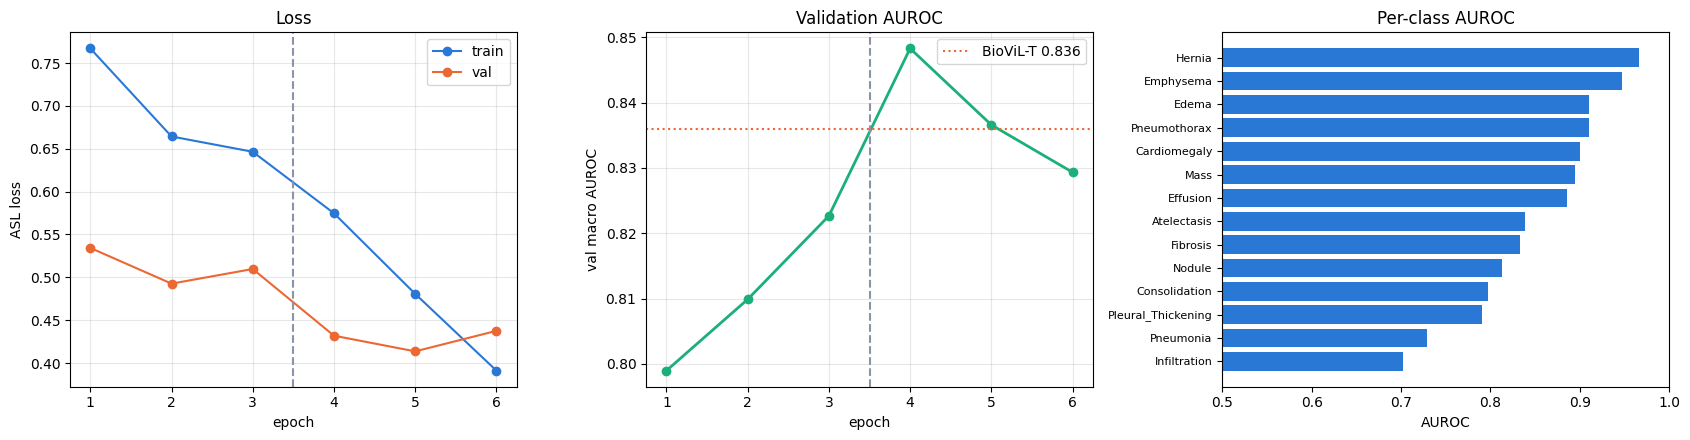

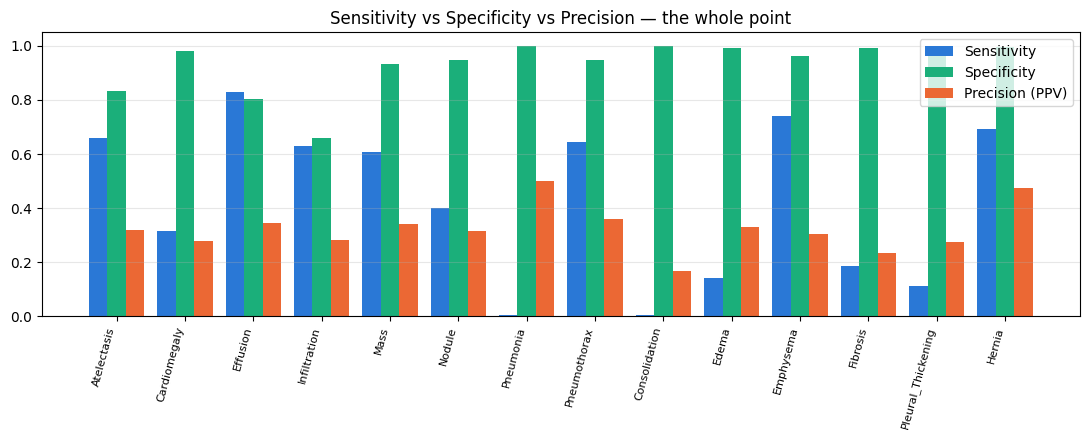

In [11]:
# ── Cell 11: figures ─────────────────────────────────────────────────────────
hist = pd.DataFrame(history, columns=["epoch", "phase", "train_loss", "val_loss", "val_auroc"])

fig, ax = plt.subplots(1, 3, figsize=(17, 4.5))

if len(hist):                       # empty when the run resumed from a checkpoint
    ax[0].plot(hist.epoch, hist.train_loss, "o-", color=C_BLUE, label="train")
    ax[0].plot(hist.epoch, hist.val_loss, "o-", color=C_ORANGE, label="val")
    ax[0].axvline(WARMUP_EPOCHS + 0.5, ls="--", color=C_GREY)
    ax[0].legend()
    ax[1].plot(hist.epoch, hist.val_auroc, "o-", color=C_AQUA, lw=2)
    ax[1].axvline(WARMUP_EPOCHS + 0.5, ls="--", color=C_GREY)
    ax[1].axhline(0.836, ls=":", color=C_ORANGE, label="BioViL-T 0.836")
    ax[1].legend()
else:
    for a in ax[:2]:
        a.text(0.5, 0.5, "training skipped\n(resumed from checkpoint)",
               ha="center", va="center", color=C_GREY, transform=a.transAxes)
ax[0].set_xlabel("epoch"); ax[0].set_ylabel("ASL loss"); ax[0].set_title("Loss")
ax[0].grid(alpha=.3)
ax[1].set_xlabel("epoch"); ax[1].set_ylabel("val macro AUROC")
ax[1].set_title("Validation AUROC"); ax[1].grid(alpha=.3)

order = r_final.sort_values("auroc", ascending=True)
ax[2].barh(range(len(order)), order["auroc"], color=C_BLUE)
ax[2].set_yticks(range(len(order))); ax[2].set_yticklabels(order.index, fontsize=8)
ax[2].axvline(0.5, ls=":", color=C_GREY)
ax[2].set_xlabel("AUROC"); ax[2].set_title("Per-class AUROC"); ax[2].set_xlim(0.5, 1.0)
plt.tight_layout(); plt.savefig(FIG_DIR / "training_and_auroc.png", dpi=150, bbox_inches="tight")
plt.show()

fig, ax = plt.subplots(figsize=(11, 4.5))
x = np.arange(NUM_CLASSES); w = 0.27
ax.bar(x - w, r_final["sensitivity"], w, label="Sensitivity", color=C_BLUE)
ax.bar(x,     r_final["specificity"], w, label="Specificity", color=C_AQUA)
ax.bar(x + w, r_final["precision"],   w, label="Precision (PPV)", color=C_ORANGE)
ax.set_xticks(x); ax.set_xticklabels(DISEASE_LABELS, rotation=75, ha="right", fontsize=8)
ax.set_title("Sensitivity vs Specificity vs Precision — the whole point")
ax.legend(); ax.grid(alpha=.3, axis="y")
plt.tight_layout(); plt.savefig(FIG_DIR / "sens_spec_prec.png", dpi=150, bbox_inches="tight")
plt.show()


In [12]:
# ── Cell 12: save (this one cannot crash) ────────────────────────────────────
results = {
    "model": MODEL_ID,
    "image_size": IMAGE_SIZE,
    "batch_size": BATCH_SIZE,
    "unfreeze_last_n": UNFREEZE_LAST_N,
    "loss": "AsymmetricLoss(gamma_neg=4, gamma_pos=1, clip=0.05)",
    "seed": SEED,
    "split": {"train": len(train_df), "val": len(val_df), "test": len(test_df),
              "test_positives": int(y_test.sum())},
    "best_val_auroc": float(best_val_auroc),
    "best_val_loss": (float(best_val_loss)
                      if math.isfinite(best_val_loss) else None),
    "calibrated_temperature": float(TEMPERATURE),
    "trainable_params": int(sum(p.numel() for p in model.parameters())),
    "test_macro_auroc": float(MACRO_AUROC),
    "test_macro_auprc": float(MACRO_AUPRC),
    "strategy_summary": sdf.reset_index().to_dict(orient="records"),
    "per_class_ppv30": r_final.reset_index().to_dict(orient="records"),
    "thresholds_ppv30": {c: float(t) for c, t in zip(DISEASE_LABELS, thr_final)},
    "stage1_triage": tri.to_dict(orient="records"),
    "history": hist.to_dict(orient="records"),
}
with open(OUT / "results.json", "w") as f:
    json.dump(results, f, indent=2, default=float)

hist.to_csv(OUT / "history.csv", index=False)
r_final.to_csv(OUT / "per_class_ppv30.csv")
sdf.to_csv(OUT / "strategy_summary.csv")

print("Saved to /kaggle/working:")
for p in sorted(OUT.rglob("*")):
    if p.is_file():
        print(f"   {p.relative_to(OUT)}  ({p.stat().st_size/1024:.1f} KB)")
print(f"\n✅ Done.  RAD-DINO test macro AUROC = {MACRO_AUROC:.4f}")
print("   probs_test_raddino.npy is ready to drop into the ensemble notebook.")


Saved to /kaggle/working:
   __notebook__.ipynb  (284.4 KB)
   checkpoints/best_model.pth  (338391.3 KB)
   checkpoints/best_model_calibrated.pth  (338393.9 KB)
   figures/sens_spec_prec.png  (78.5 KB)
   figures/training_and_auroc.png  (132.9 KB)
   history.csv  (0.4 KB)
   logits_test_raddino.npy  (870.6 KB)
   logits_val_raddino.npy  (962.1 KB)
   per_class_ppv30.csv  (3.0 KB)
   probs_test_raddino.npy  (870.6 KB)
   probs_val_raddino.npy  (962.1 KB)
   results.json  (10.3 KB)
   strategy_summary.csv  (0.8 KB)

✅ Done.  RAD-DINO test macro AUROC = 0.8513
   probs_test_raddino.npy is ready to drop into the ensemble notebook.
